In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import least_squares

In [2]:
mpl.rcParams['figure.dpi'] = 150

In [80]:
def read_transition(filename, mu_min_data=-np.inf, mu_max_data=np.inf, mu_min_fit=-np.inf, mu_max_fit=np.inf, 
                    column_mu=0, columns_sigma=(1,2), skiprows=0, least_spacing=0.01):
    columns = (column_mu,) + columns_sigma
    data = np.loadtxt(filename, usecols=columns, skiprows=skiprows)
    data = data[(data[:,0] >= mu_min_data) & (data[:,0] <= mu_max_data)]
    answer = [[data[0,0], (data[0,1] + data[0,2]) / 2, data[0,2] - data[0,1]]]
    for i in range(1, len(data)):
        if data[i,0] - answer[-1][0] >= least_spacing:
            answer.append([data[i,0], (data[i,1] + data[i,2]) / 2, data[i,2] - data[i,1]])

    data_filtered = data[(data[:,0] >= mu_min_fit) & (data[:,0] <= mu_max_fit)]
    answer_filtered = [[data_filtered[0,0], (data_filtered[0,1] + data_filtered[0,2]) / 2, data_filtered[0,2] - data_filtered[0,1]]]
    for i in range(1, len(data_filtered)):
        if data_filtered[i,0] - answer_filtered[-1][0] >= least_spacing:
            answer_filtered.append([data_filtered[i,0], (data_filtered[i,1] + data_filtered[i,2]) / 2, data_filtered[i,2] - data_filtered[i,1]])
    return np.array(answer), np.array(answer_filtered)

In [81]:
def read_all_transitions(N_list, path, eps, lda, tol_fixed_point, c, T, 
                         mu_min_data=-np.inf, mu_max_data=np.inf, mu_min_fit=-np.inf, mu_max_fit=np.inf, 
                         colum_mu=0, columns_sigma=(1,2), skiprows=0, least_spacing=0.01):
    all_data = {}
    all_data_filtered = {}
    for N in N_list:
        filename = f'{path}/Lotka-Volterra_transition_div_epsilon_{eps}_Partially_AsymGauss_lambda_{lda}_tol_{tol_fixed_point}_N_{N}_c_{c}_T_{T}.txt'
        data, data_filtered = read_transition(filename, mu_min_data=mu_min_data, mu_max_data=mu_max_data, mu_min_fit=mu_min_fit, 
                                              mu_max_fit=mu_max_fit, column_mu=colum_mu, columns_sigma=columns_sigma, 
                                              skiprows=skiprows, least_spacing=least_spacing)
        all_data[N] = data
        all_data_filtered[N] = data_filtered
    return all_data, all_data_filtered

In [69]:
def residuals(A, c, all_data, unique_A=False, min_N=0, weights=None):
    if weights is None:
        weights = {}
        for N in all_data:
            weights[N] = 1.0
    counter = 0
    res = []
    for N in all_data:
        if N > min_N:
            data = all_data[N]
            mu_values = data[:,0]
            observed_sigma = data[:,1]
            if unique_A:
                predicted_sigma = np.sqrt(1 + 2 * mu_values * np.sqrt(c)) / (A* np.sqrt(np.log(N))) 
            else:
                predicted_sigma = np.sqrt(1 + 2 * mu_values * np.sqrt(c)) / (A[counter]* np.sqrt(np.log(N)))
                counter += 1
            res.extend((observed_sigma - predicted_sigma) * weights[N])
    return np.array(res)

In [70]:
def make_fit(c, all_data, initial_guess, unique_A=False, min_N=0, weights=None):
    result = least_squares(residuals, initial_guess, args=(c, all_data, unique_A, min_N, weights))
    print("Optimized parameters:", result.x)
    print("Cost function value:", result.cost / len(all_data.keys()))
    return result.x

In [71]:
def plot_fits(all_data, min_mu, optimized_A, c, unique_A=False):
    plt.figure()
    colors = plt.cm.viridis(np.linspace(0, 1, len(all_data)))
    for idx, N in enumerate(all_data):
        data = all_data[N]
        mu_values = data[:,0]
        mu_values_plot = np.linspace(min_mu, max(mu_values), 1000)
        observed_sigma = data[:,1]
        errors = data[:,2]
        plt.scatter(mu_values, observed_sigma, label=f'N={N}', color=colors[idx], s=10)
        plt.errorbar(mu_values, observed_sigma, yerr=errors, color=colors[idx], linestyle='None', capsize=2, alpha=0.5)
        if unique_A:
            predicted_sigma = np.sqrt(1 + 2 * mu_values_plot * np.sqrt(c)) / (optimized_A * np.sqrt(np.log(N)))
        else:
            predicted_sigma = np.sqrt(1 + 2 * mu_values_plot * np.sqrt(c)) / (optimized_A[idx] * np.sqrt(np.log(N)))
        plt.plot(mu_values_plot, predicted_sigma, color=colors[idx])
    plt.xlabel(r'$\mu$')
    plt.ylabel(r'$\sigma$')
    plt.legend()
    plt.show()

In [72]:
eps = "0.0"
lda = "1e-06"
N_list = [128, 256, 512, 1024, 2048, 4096, 8192]
c = "3.00"
T = "0.0"
tol_fixed_point = "1e-08"

# path = "/media/david/Seagate Expansion Drive/Salva/Salva_Data_Investigacion/Grupo_de_investigacion/Ecology/Langevin/Results/"
path = "/mnt/d/Research/Ecology/Langevin/Results/"

In [82]:
mu_min_fit = -0.2
mu_max_data = 0.34
all_data, all_data_filtered = read_all_transitions(N_list, path, eps, lda, tol_fixed_point, c, T, 
                                                   mu_max_data=mu_max_data, mu_min_fit=mu_min_fit, least_spacing=0.029)

Optimized parameters: [0.87855897 0.90244266 0.91945328 0.93299455 0.94568709 0.95571608
 0.96335447]
Cost function value: 0.0007804305117803221


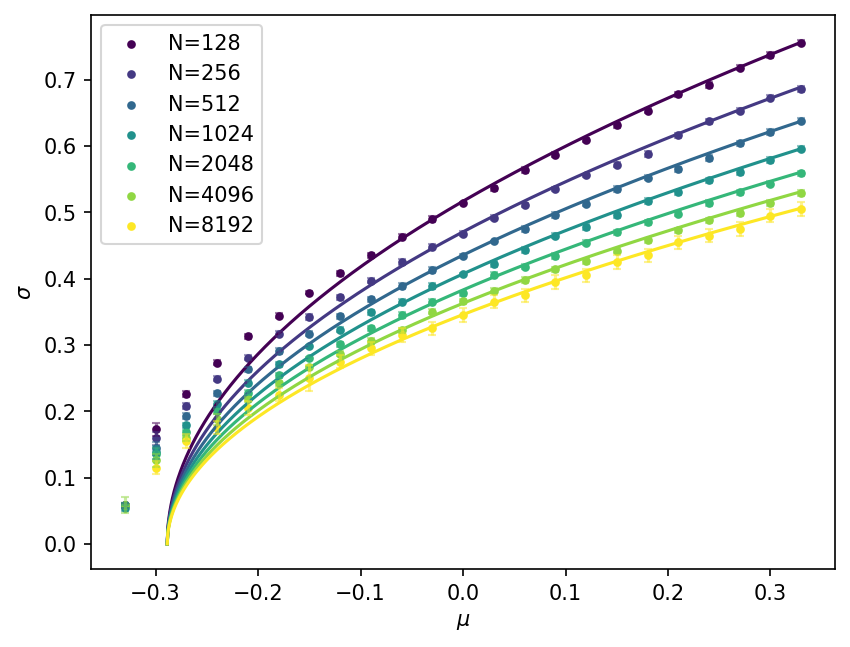

In [83]:
Ainit = [1.0 for _ in N_list]
optimized_A = make_fit(float(c), all_data_filtered, Ainit, unique_A=False)
min_mu_plot = -1.0 / (2 * np.sqrt(float(c)))
plot_fits(all_data, min_mu_plot, optimized_A, float(c), unique_A=False)

Optimized parameters: [0.95536451]
Cost function value: 0.03714116795347503


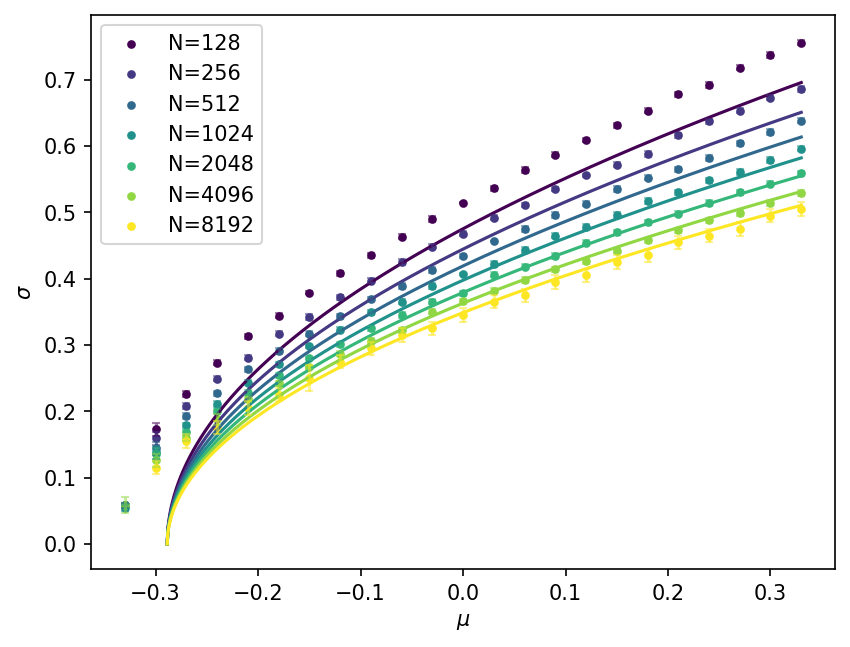

In [86]:
Ainit = 1.0
min_N = 1024
weights = {N: np.log2(N) for N in N_list}
optimized_A = make_fit(float(c), all_data_filtered, Ainit, unique_A=True, min_N=min_N, weights=weights)
min_mu_plot = -1.0 / (2 * np.sqrt(float(c)))
plot_fits(all_data, min_mu_plot, optimized_A, float(c), unique_A=True)